In [27]:
import pandas as pd
import torch
import clip
import requests
from PIL import Image
from io import BytesIO
from transformers import pipeline
import matplotlib.pyplot as plt
import streamlit as st

In [28]:
df = pd.read_csv("Best_Bank.csv") 

In [29]:
df

,Customer Name,Visit Date,Bank Name,Rating,Comment,bank_image
0,AMRENDRA T,"Mar 21, 2020",SBI,🙂,"""Best saving""",https://static.bankbazaar.com/images/common/ba...
1,BISHWA,"Mar 20, 2020",SBI,😀,"""Good service""",https://static.bankbazaar.com/images/common/ba...
2,SANTOSH,"Mar 20, 2020",Axis Bank,😀,"""Excellent Service""",https://static.bankbazaar.com/images/common/ba...
3,MAHADEV,"Mar 20, 2020",HDFC Bank,😀,"""Excellent service""",https://static.bankbazaar.com/images/common/ba...
4,MD,"Mar 20, 2020",IDBI,😀,"""Good """,https://static.bankbazaar.com/images/common/ba...
...,...,...,...,...,...,...
710,ANONYMS,"Nov 26, 2019",SBI,🙂,"""Process has to be fast""",https://static.bankbazaar.com/images/common/ba...
711,M,"Nov 26, 2019",Punjab National Bank,🙂,"""Good """,https://static.bankbazaar.com/images/common/ba...
712,A L,"Nov 26, 2019",Axis Bank,🙂,"""Mobile app is good""",https://static.bankbazaar.com/images/common/ba...
713,ANONYMS,"Nov 26, 2019",Axis Bank,🙂,"""Unhappy with the charges""",https://static.bankbazaar.com/images/common/ba...


In [30]:
emoji_scores = {
    "😍": 1.0, "😊": 0.7, "😐": 0.5, "😡": 0.0
}


In [31]:
df["Rating Score"] = df["Rating"].map(emoji_scores)

In [32]:
# Specify the model explicitly
model_name = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"
sentiment_analysis_pipeline = pipeline("sentiment-analysis", model=model_name)

Device set to use cpu


In [33]:
sentiment_analyzer = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


In [34]:
def get_sentiment_score(comment):
    if pd.isna(comment):  # Handle missing values
        return 0
    result = sentiment_analyzer(comment)[0]
    return result["score"] * (1 if result["label"] == "POSITIVE" else -1)

In [35]:
df["Sentiment Score"] = df["Comment"].apply(get_sentiment_score)

In [36]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

In [37]:
def get_image_score(image_url):
    try:
        response = requests.get(image_url, timeout=5)
        image = Image.open(BytesIO(response.content))
        image = preprocess(image).unsqueeze(0).to(device)
        
        with torch.no_grad():
            image_features = model.encode_image(image)
        
        return image_features.norm().item()  # Normalize score
    except:
        return 0  # Default score if image processing fails


In [38]:
df["Image Score"] = df["bank_image"].apply(get_image_score)

C:\Users\User\anaconda3\Lib\site-packages\PIL\Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [47]:
df = df.dropna(subset=["Rating Score", "Final Score"])

In [48]:
df["Final Score"] = (df["Sentiment Score"] * 0.5) + (df["Rating Score"] * 0.3) + (df["Image Score"] * 0.2)

C:\Users\User\AppData\Local\Temp\ipykernel_2588\2455639663.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Final Score"] = (df["Sentiment Score"] * 0.5) + (df["Rating Score"] * 0.3) + (df["Image Score"] * 0.2)


In [49]:
results_table = df.groupby("Bank Name")[["Final Score", "Sentiment Score", "Rating Score", "Image Score"]].mean()

In [50]:
results_table_sorted = results_table.sort_values(by="Final Score", ascending=False)

In [51]:
print("🏆 Table of Results based on Final Scores 🏆")
print(results_table_sorted)

🏆 Table of Results based on Final Scores 🏆
                      Final Score  Sentiment Score  Rating Score  Image Score
Bank Name                                                                    
IndusInd Bank            3.013405         0.999867      0.500000    11.817355
IDBI                     2.854738         0.999813      0.500000    11.024158
HDFC Bank                2.343797         0.151689      0.428571    10.696907
Canara Bank              2.185329        -0.124301      0.428571    10.594539
Axis Bank                2.113595        -0.048379      0.500000     9.938924
SBI                      2.009630        -0.564541      0.421053    10.827923
Kotak                    1.787182        -0.488843      0.375000     9.595515
Punjab National Bank     1.772152        -0.971576      0.500000    10.539701


In [52]:
best_bank = df.groupby("Bank Name")["Final Score"].mean().idxmax() 
print(f"🏆 Best Bank: {best_bank}")

🏆 Best Bank: IndusInd Bank


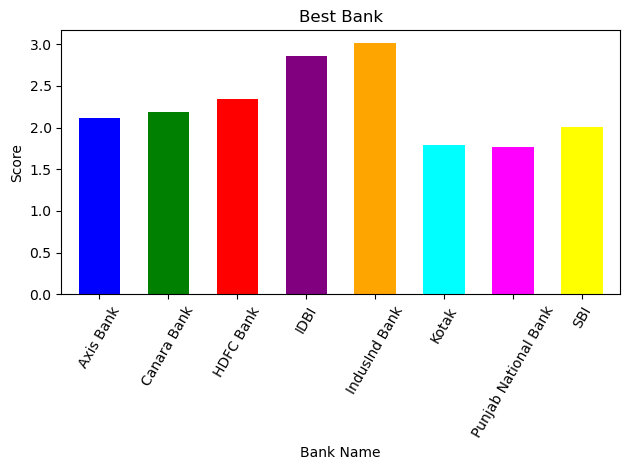

In [53]:
# List of colors
colors = ["blue", "green", "red", "purple", "orange", "cyan", "magenta", "yellow", "brown", "pink"]

# Plot
df.groupby("Bank Name")["Final Score"].mean().plot(
   kind="bar",
    color=colors[:len(df["Bank Name"].unique())],
    width=0.60   # <-- increase width to reduce gaps
)

plt.title("Best Bank")
plt.ylabel("Score")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

In [54]:
import pandas as pd

In [55]:
bank_sentiment = df.groupby("Bank Name")["Sentiment Score"].mean()

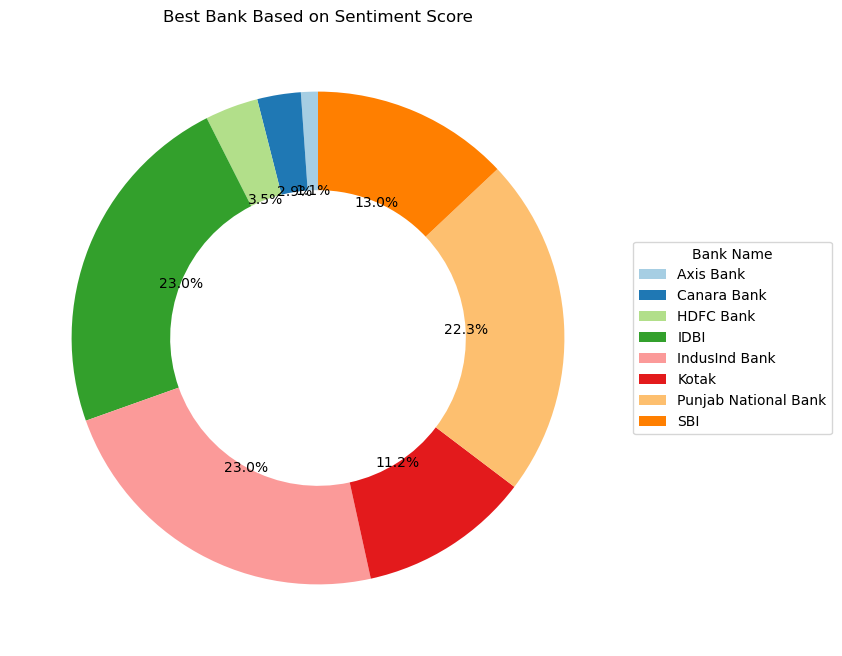

In [63]:
# Ensure all sentiment scores are non-negative by taking the absolute value
bank_sentiment = df.groupby("Bank Name")["Sentiment Score"].mean()

# If there are negative values, convert them to positive (optional)
bank_sentiment = bank_sentiment.abs()

# Plot the pie chart again
plt.figure(figsize=(8, 8))
plt.pie(
    bank_sentiment,
    #labels=bank_sentiment.index,  # Labels with bank names
    colors=plt.cm.Paired.colors,
    startangle=90,  # Rotate so it looks nicer
    wedgeprops=dict(width=0.4),  # Make it a donut by setting width < 1
    autopct='%1.1f%%'  # Display percentages with one decimal point
)

# Add legend outside
plt.legend(
    bank_sentiment.index,
    title="Bank Name",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title("Best Bank Based on Sentiment Score")
plt.show()